<a href="https://colab.research.google.com/github/yoloaryan/CNN/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

In [ ]:
from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:


df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")


In [ ]:


df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_test

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(29240, 785)

In [ ]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29240 entries, 0 to 29239
Columns: 785 entries, label to 28x28
dtypes: float64(722), int64(63)
memory usage: 175.1 MB


In [ ]:


df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,1
28x25,1
28x26,1
28x27,1


In [ ]:
df = df.dropna()
df_test = df_test.dropna()

df.fillna(0, inplace=True)
df_test.fillna(0, inplace=True)

#preprocess
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [ ]:

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
X_train_img = X_train.reshape(-1, 28, 28) # here -1 is the first row and there is 28*28 image pixel
X_test_img = X_test.reshape(-1, 28, 28)

In [ ]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [ ]:

# covert this into categories
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
from tensorflow.keras.models import Sequential

perceptron = Sequential([
    Flatten(input_shape=(28,28)), # flatten covert 28*28 matrix into the 1d array
    Dense(10, activation="softmax") #softmax is good for mulgti class variable

])

In [ ]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])


In [ ]:
history_perceptron = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8959 - loss: 0.3903 - val_accuracy: 0.9006 - val_loss: 0.3700
Epoch 2/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8981 - loss: 0.3772 - val_accuracy: 0.9025 - val_loss: 0.3588
Epoch 3/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9000 - loss: 0.3668 - val_accuracy: 0.9045 - val_loss: 0.3514
Epoch 4/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9023 - loss: 0.3583 - val_accuracy: 0.9062 - val_loss: 0.3446
Epoch 5/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9039 - loss: 0.3511 - val_accuracy: 0.9074 - val_loss: 0.3389


In [ ]:
acc_perceptron = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [ ]:
acc_ann

0.09799999743700027

In [ ]:
#ANN
from tensorflow.keras.layers import BatchNormalization, Activation

ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128),
    BatchNormalization(), # Add BatchNormalization layer
    Activation("relu"),   # Then ReLU activation
    Dense(64),
    BatchNormalization(), # Add BatchNormalization layer
    Activation("relu"),   # Then ReLU activation
    Dense(10,activation="softmax")
])

In [ ]:
ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_ann_model = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7603 - loss: 0.8889 - val_accuracy: 0.9051 - val_loss: 0.4139
Epoch 2/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9069 - loss: 0.3835 - val_accuracy: 0.9336 - val_loss: 0.2623
Epoch 3/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9301 - loss: 0.2745 - val_accuracy: 0.9422 - val_loss: 0.2072
Epoch 4/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9423 - loss: 0.2202 - val_accuracy: 0.9519 - val_loss: 0.1732
Epoch 5/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9515 - loss: 0.1819 - val_accuracy: 0.9577 - val_loss: 0.1503


In [ ]:
acc_ann_model = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [ ]:


X_train_cnn = X_train.reshape(-1, 28, 28,1) # 1 is the layer(channels)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [ ]:


cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [ ]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)


Epoch 1/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 32s 33ms/step - accuracy: 0.7850 - loss: 0.7378 - val_accuracy: 0.9443 - val_loss: 0.2033
Epoch 2/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9272 - loss: 0.2509 - val_accuracy: 0.9601 - val_loss: 0.1319
Epoch 3/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9465 - loss: 0.1818 - val_accuracy: 0.9708 - val_loss: 0.1005
Epoch 4/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9566 - loss: 0.1490 - val_accuracy: 0.9755 - val_loss: 0.0794
Epoch 5/5
914/914 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.9612 - loss: 0.1267 - val_accuracy: 0.9756 - val_loss: 0.0792


In [ ]:


acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [ ]:
acc_cnn

0.975600004196167

In [ ]:


def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

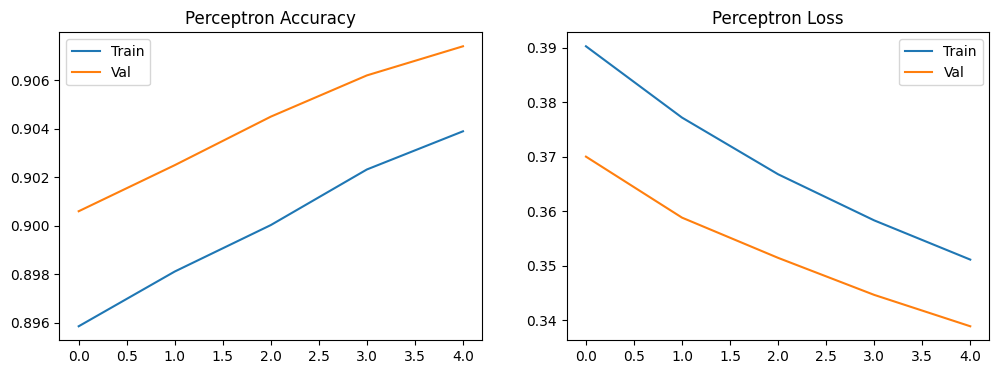

In [ ]:
plot_training(history_perceptron, "Perceptron")


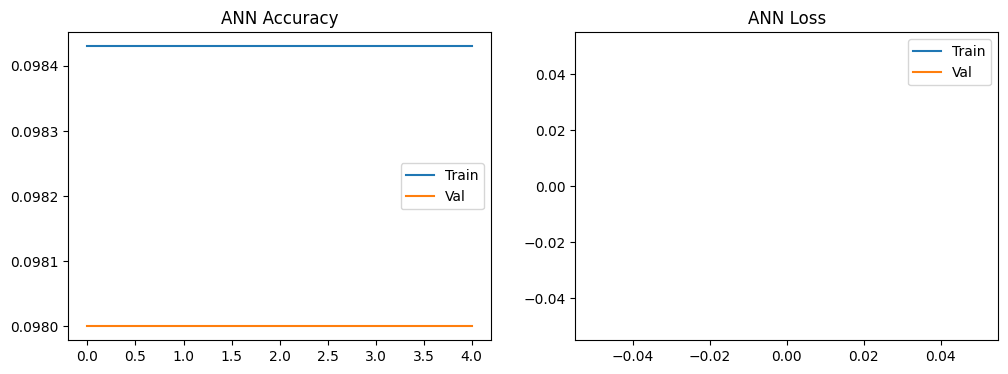

In [ ]:

plot_training(history_ann_model, "ANN")

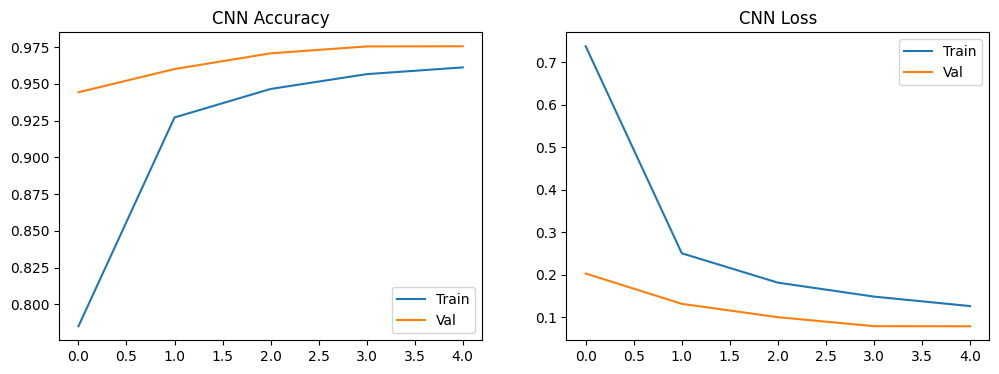

In [ ]:


plot_training(history_cnn, "CNN")

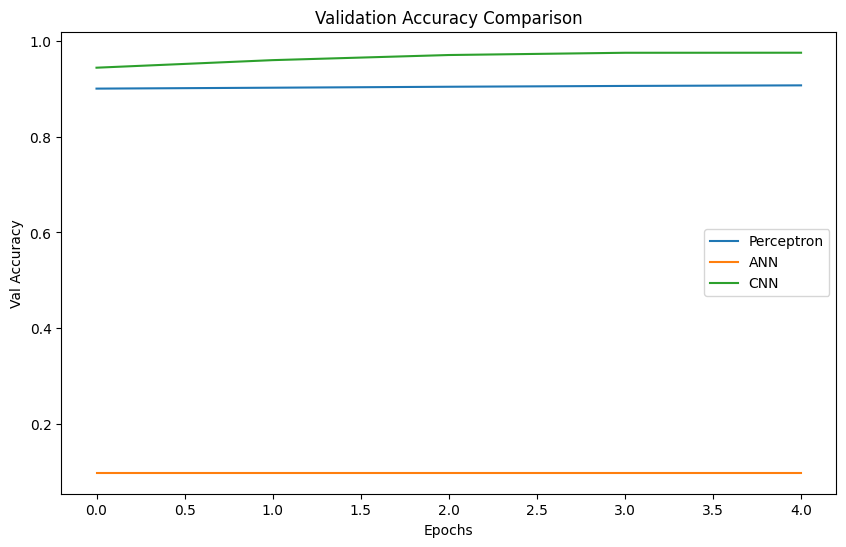

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history_perceptron.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann_model.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [ ]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


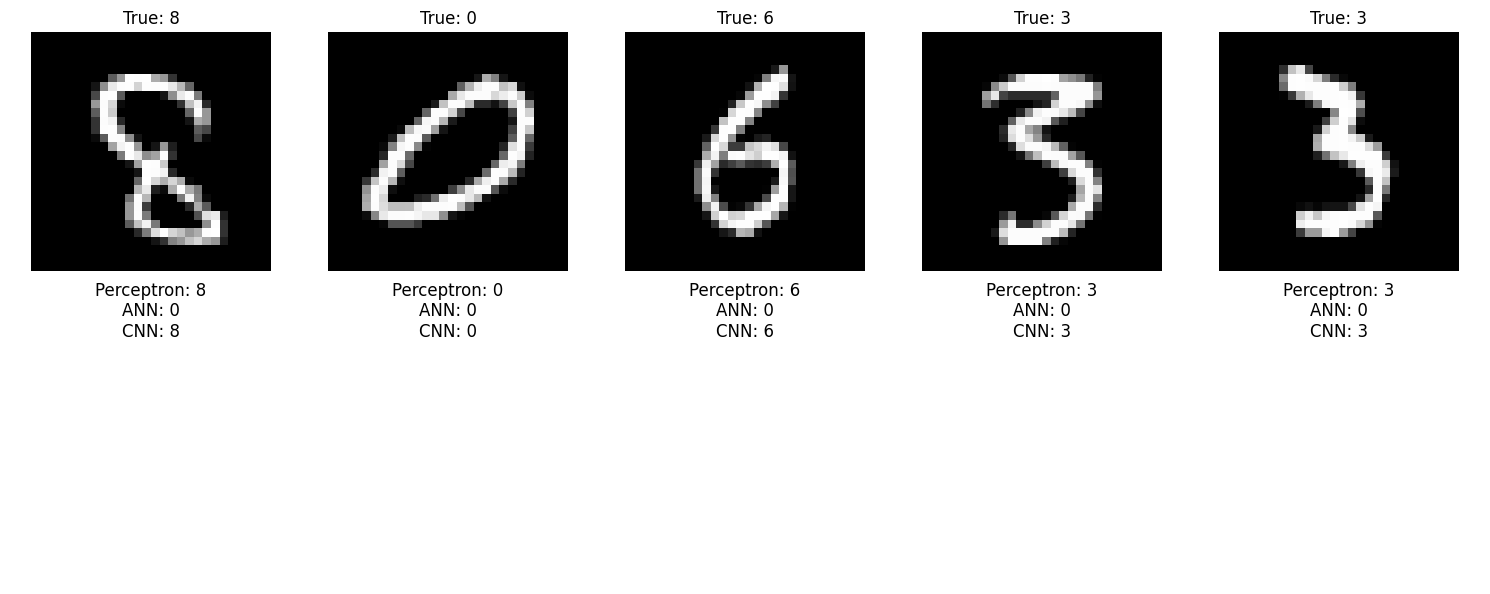

In [ ]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


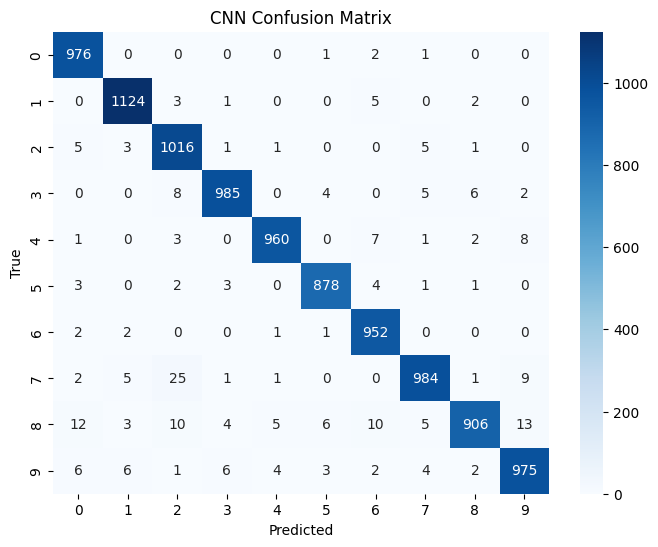

In [ ]:


y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

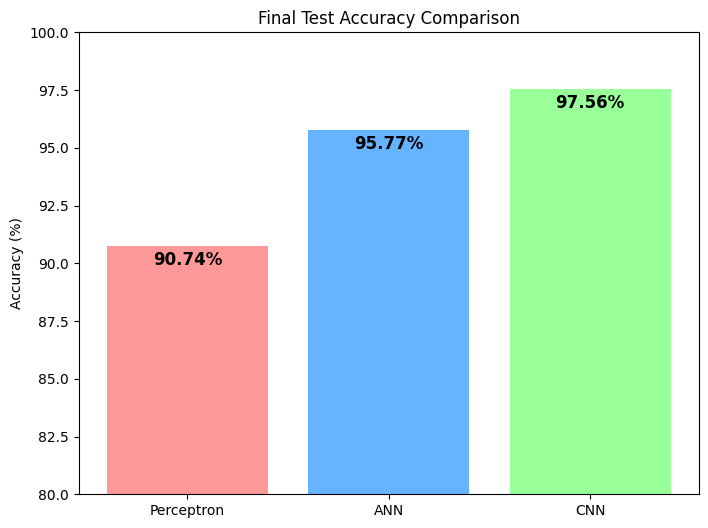

In [ ]:

final_accs = [acc_perceptron*100, acc_ann_model*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()

In [ ]:
y_pred_perceptron = np.argmax(perceptron.predict(X_test_img), axis=1)
y_pred_ann = np.argmax(ann.predict(X_test_img), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


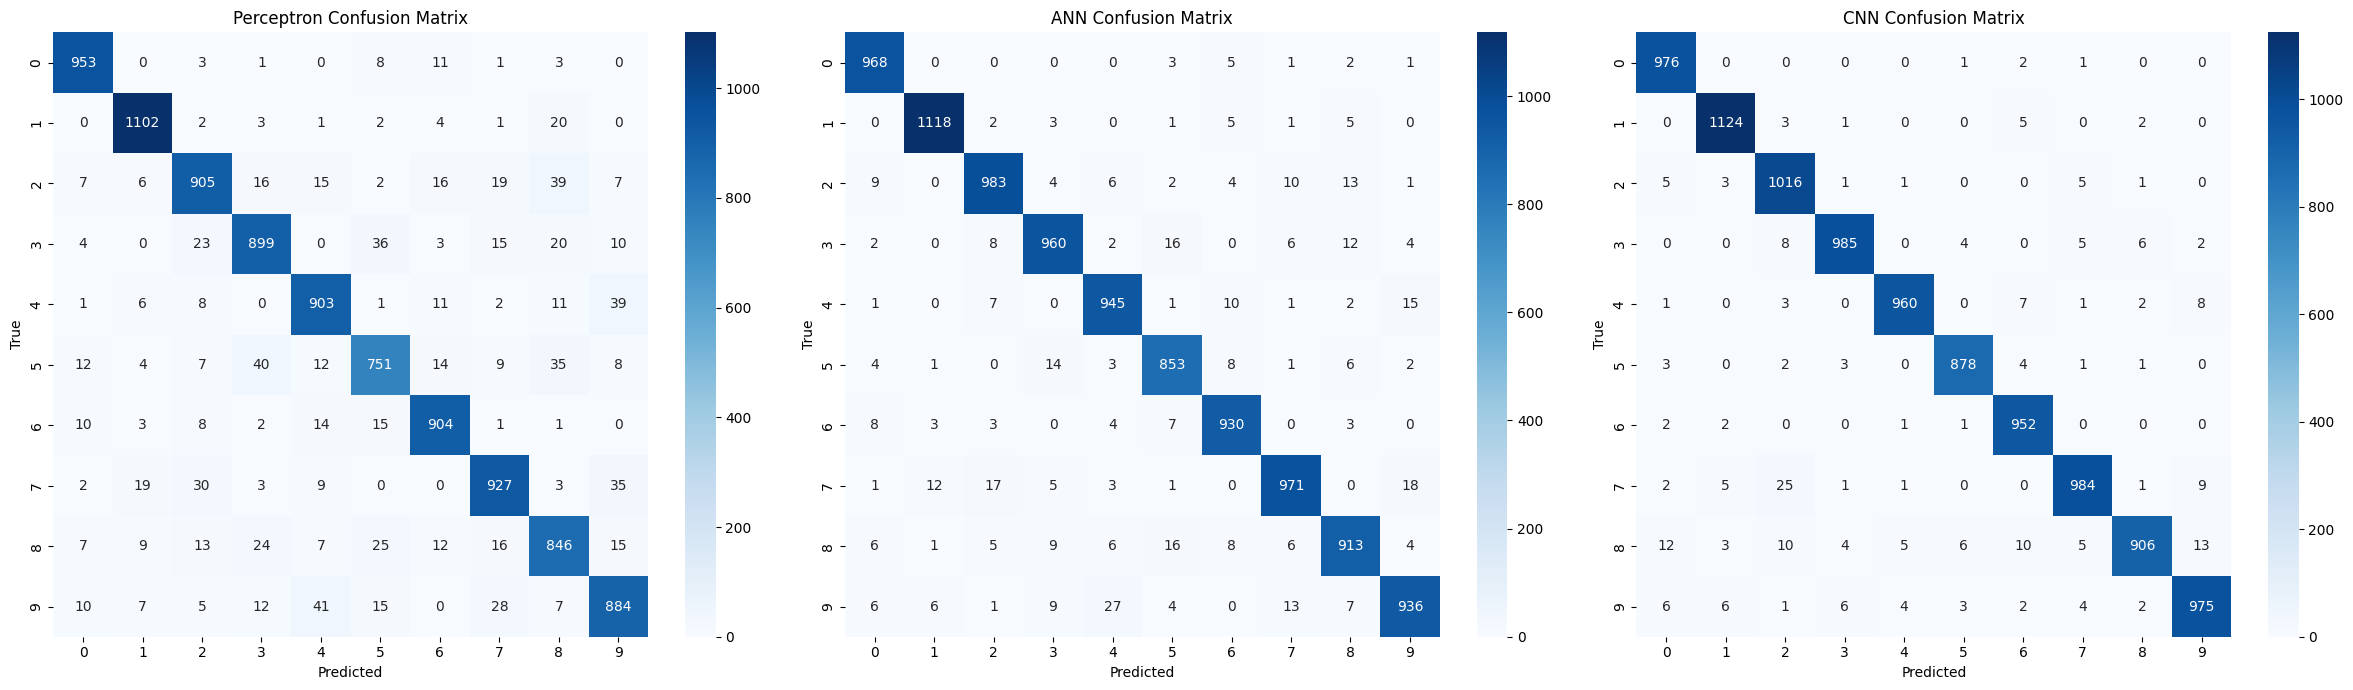

In [ ]:
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)
cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_cnn = confusion_matrix(y_test, y_pred_cnn) # Re-use the existing CNN confusion matrix

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(cm_perceptron, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Perceptron Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("ANN Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("CNN Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()